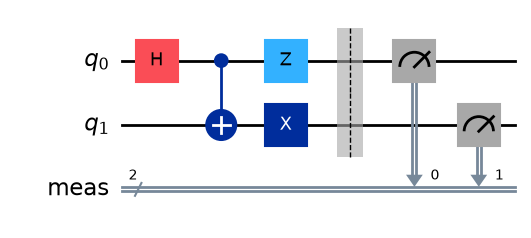

In [1]:
from ibm import *
import qiskit

# Make state
qc = qiskit.QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

Registered backend: ibm_marrakesh
Circuit optimized


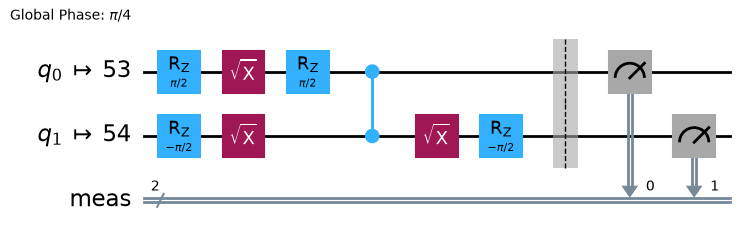

In [2]:
backend = register_backend('secrets.yaml')
optimized_qc = transpile(qc, backend, optimization_level=3)
optimized_qc.draw("mpl")

job registered
job results obtained: PrimitiveResult([SamplerPubResult(data=DataBin(meas=BitArray(<shape=(), num_shots=100, num_bits=2>)), metadata={'circuit_metadata': {}})], metadata={'execution': {'execution_spans': ExecutionSpans([DoubleSliceSpan(<start='2026-08-03 05:05:52', stop='2026-08-03 05:05:52', size=100>)])}, 'version': 2})
Counts: {'10': 44, '01': 55, '11': 1}


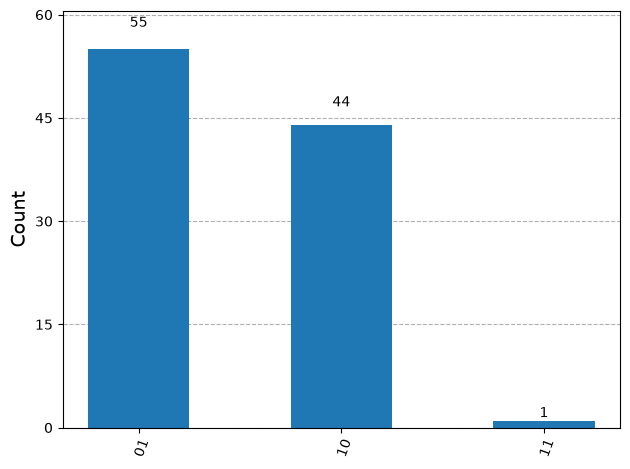

In [3]:
counts = run_transpiled_circuit_and_get_counts(optimized_qc, backend, shots=100)
print(f"Counts: {counts}")
qiskit.visualization.plot_histogram(counts)

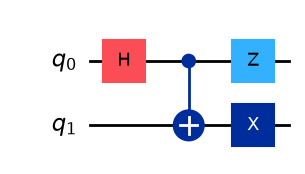

In [4]:
# Parameters
J = 1.0 # anti-ferromagentic coupling(J<0)
hx = -0.5 # transverse field strength

# Hamiltonian H = J Z1 Z2 + hx (X1 + X2)
obs = qiskit.quantum_info.SparsePauliOp.from_list([
    ("ZZ", J),
    ("XI", hx),
    ("IX", hx)
])

# Make state again, but do NOT measure all, we will use Estimator instead
qc2 = qiskit.QuantumCircuit(2)
qc2.h(0)
qc2.cx(0, 1)
qc2.x(1)
qc2.z(0)

qc2.draw("mpl")

Registered backend: ibm_marrakesh
Circuit optimized


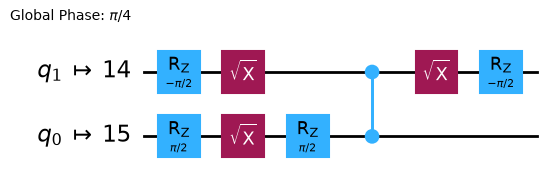

In [5]:
backend = register_backend('secrets.yaml')
qc2_isa = transpile(qc2, backend, optimization_level=3)
obs_isa = obs.apply_layout(layout=qc2_isa.layout)
qc2_isa.draw("mpl")

In [6]:
estimator = qiskit_ibm_runtime.EstimatorV2(mode=backend)

# Load the backend sampler
# noise_model = NoiseModel.from_backend(backend)

# Use Aer simulator in Estimator
# estimator_sim = BackendEstimatorV2(backend=backend_sim)

# Alternatively, load a fake backend with generic properties and define a simulator.
# backend_gen = GenericBackendV2(num_qubits=18)
# estimator_gen = BackendEstimatorV2(backend=backend_gen)

pubs = [(qc2_isa, obs_isa)]
job = estimator.run([[qc2_isa, obs_isa]])
print("Registered job")
res = job.result()
print(f"Got results from job: {res}")
print(f"Energy for LESSON state: {res[0].data.evs}")
# Uncomment lines below to run the job on the Aer simulator with noise model from real backend
# job = estimator_sim.run([[qc_isa,obs_isa]])
# res=job.result()



Registered job
Got results from job: PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 4096, 'target_precision': 0.015625, 'circuit_metadata': {}, 'resilience': {}, 'num_randomizations': 32})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': True, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': True, 'zne_mitigation': False, 'pec_mitigation': False}, 'version': 2})
Energy for LESSON state: -0.9907436921247683


In [7]:
# HOMEWORK - find lower energy state
results = {"LESSON": res[0].data.evs}

def run_experiment(qc):
    backend = register_backend('secrets.yaml')
    qc_isa = transpile(qc, backend, optimization_level=3)
    obs_isa = obs.apply_layout(layout=qc_isa.layout)
    pubs = [(qc_isa, obs_isa)]
    job = estimator.run([[qc_isa, obs_isa]])
    print("Registered job")
    res = job.result()
    energy = res[0].data.evs
    return energy

results["BELL_PHI+"] = run_experiment(generate_bell_phi_plus())
print(f"[RESULT] Energy for BELL_PHI+ state: ", results["BELL_PHI+"])

Registered backend: ibm_marrakesh
Circuit optimized
Registered job
[RESULT] Energy for BELL_PHI+ state:  0.9758527530201007


In [8]:
results["BELL_PHI-"] = run_experiment(generate_bell_phi_minus())
print(f"[RESULT] Energy for BELL_PHI- state: ", results["BELL_PHI-"])

Registered backend: ibm_marrakesh
Circuit optimized
Registered job
[RESULT] Energy for BELL_PHI- state:  0.9958461797029907


In [9]:
results["BELL_PSI+"] = run_experiment(generate_bell_psi_plus())
print(f"[RESULT] Energy for BELL_PSI+ state: ", results["BELL_PSI+"])

Registered backend: ibm_marrakesh
Circuit optimized
Registered job
[RESULT] Energy for BELL_PSI+ state:  -0.9611321080065076


In [10]:
results["BELL_PSI-"] = run_experiment(generate_bell_psi_minus())
print(f"[RESULT] Energy for BELL_PSI- state: ", results["BELL_PSI-"])

Registered backend: ibm_marrakesh
Circuit optimized
Registered job
[RESULT] Energy for BELL_PSI- state:  -0.9962104037631133


In [11]:
ground_energy_state = min(results, key=results.get)
print(f"[FINAL RESULT] Ground energy state is {ground_energy_state} with energy {results[ground_energy_state]}")
for state in results: print(f"{state}: {results[state]}")

[FINAL RESULT] Ground energy state is BELL_PSI- with energy -0.9962104037631133
LESSON: -0.9907436921247683
BELL_PHI+: 0.9758527530201007
BELL_PHI-: 0.9958461797029907
BELL_PSI+: -0.9611321080065076
BELL_PSI-: -0.9962104037631133
